In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
Temporal / Multilayer Network Analysis — Italy & US Earthquake Networks

Supplementary notebook extending the main Abe-Suzuki analysis.
Builds one 10-km network per 5-year window (1985–2024) for both catalogs
and tracks how topology, communities, and hubs evolve across windows.

Run as script  : python extras_temporal.py
Convert to notebook: python convert_to_notebook.py extras_temporal.py notebooks/extras_temporal.ipynb
"""

import logging
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.io as pio
import seaborn as sns

from src.temporal import (
    build_temporal_networks,
    compute_temporal_metrics,
    compute_partition_stability,
    compute_hub_persistence,
    compute_edge_turnover,
    plot_temporal_metrics,
    plot_temporal_stability,
    plot_temporal_comparison,
)
from src.plotutils import setup_matplotlib, configure_saves, savefig

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")
sns.set_theme(style="whitegrid")
pio.renderers.default = "notebook"

ITALY_DATA  = Path("data/INGV/italy_earthquakes_1985_2025.csv")
US_DATA     = Path("data/USGS/us_earthquakes_1985_2025.csv")
RESULTS_DIR = Path("results")
CACHE_DIR   = RESULTS_DIR / "cache"

ITALY_CRS = "epsg:32632"
US_CRS    = "epsg:5070"
CELL_SIZE = 10
WINDOW_YEARS = 5
CUT_YEAR  = 1985
TOP_N_HUBS = 20

SAVE_PDF: bool = True
SAVE_JPG: bool = True

setup_matplotlib()
configure_saves(SAVE_JPG, SAVE_PDF, RESULTS_DIR / "figures" / "comparison")

INFO  Figure saving ON → results/figures/comparison  (PDF=True JPG=True)


## Data Loading

Both catalogs are loaded and filtered to 1985–2024 (complete-decade boundary).
A 5-year window starting at 1985 gives eight non-overlapping windows:
1985–1989, 1990–1994, ..., 2020–2024.

**Why temporal windows?** The static 40-year network aggregates all transitions.
Temporal windows reveal whether the observed scale-free topology, community
structure, and dominant hubs are **stationary** (consistent across decades) or
**episodic** (driven by specific mainshock sequences such as L'Aquila 2009 or
Ridgecrest 2019). A temporally stable network is a stronger scientific claim.

In [2]:
print("Loading earthquake catalogs...")
df_italy = pd.read_csv(ITALY_DATA)
df_italy["time"] = pd.to_datetime(df_italy["time"], utc=True)
df_italy = (
    df_italy[df_italy["time"].dt.year >= CUT_YEAR]
    .sort_values("time").reset_index(drop=True)
)

df_us = pd.read_csv(US_DATA)
df_us["time"] = pd.to_datetime(df_us["time"], utc=True)
df_us = (
    df_us[df_us["time"].dt.year >= CUT_YEAR]
    .sort_values("time").reset_index(drop=True)
)

print(f"Italy: {len(df_italy):,} events  "
      f"({df_italy['time'].dt.year.min()}–{df_italy['time'].dt.year.max()})")
print(f"US:    {len(df_us):,} events  "
      f"({df_us['time'].dt.year.min()}–{df_us['time'].dt.year.max()})")

Loading earthquake catalogs...
Italy: 215,679 events  (1985–2025)
US:    689,530 events  (1985–2025)


## Temporal Network Construction — Italy

Each 5-year window yields an independent Abe-Suzuki network built from that
window's earthquake sequence.  The networks share the same cell grid but
differ in which cells are active and how they are connected — allowing direct
window-to-window comparison of community partitions and hub rankings.

**Runtime note:** each window calls `build_abe_suzuki_network`, which projects
and discretises the catalog (~10–30 s per window depending on event count).
Total runtime for both catalogs: ~5–15 minutes.

In [3]:
print("\nBuilding Italy temporal networks (5-year windows)...")
italy_temporal = build_temporal_networks(
    df_italy,
    window_years=WINDOW_YEARS,
    cell_size_km=CELL_SIZE,
    target_crs=ITALY_CRS,
    min_events=100,
)
print(f"Italy: {len(italy_temporal)} windows built")
for label, G in italy_temporal:
    print(f"  {label}: {G.number_of_nodes():>5} nodes  {G.number_of_edges():>6} edges")

INFO  Building network for 1985–1989  (10588 events)...
INFO  Projecting to epsg:32632, cell size 10 km ...



Building Italy temporal networks (5-year windows)...


INFO  Network (10 km, epsg:32632): 4355 nodes, 10054 edges, 252 self-loops — 0.2s
INFO    → 4355 nodes  10054 edges
INFO  Building network for 1990–1994  (11457 events)...
INFO  Projecting to epsg:32632, cell size 10 km ...
INFO  Network (10 km, epsg:32632): 4619 nodes, 10652 edges, 288 self-loops — 0.2s
INFO    → 4619 nodes  10652 edges
INFO  Building network for 1995–1999  (15715 events)...
INFO  Projecting to epsg:32632, cell size 10 km ...
INFO  Network (10 km, epsg:32632): 3445 nodes, 10901 edges, 237 self-loops — 0.2s
INFO    → 3445 nodes  10901 edges
INFO  Building network for 2000–2004  (13108 events)...
INFO  Projecting to epsg:32632, cell size 10 km ...
INFO  Network (10 km, epsg:32632): 3374 nodes, 10660 edges, 292 self-loops — 0.2s
INFO    → 3374 nodes  10660 edges
INFO  Building network for 2005–2009  (27399 events)...
INFO  Projecting to epsg:32632, cell size 10 km ...
INFO  Network (10 km, epsg:32632): 5199 nodes, 17969 edges, 457 self-loops — 0.3s
INFO    → 5199 nodes  

Italy: 8 windows built
  1985–1989:  4355 nodes   10054 edges
  1990–1994:  4619 nodes   10652 edges
  1995–1999:  3445 nodes   10901 edges
  2000–2004:  3374 nodes   10660 edges
  2005–2009:  5199 nodes   17969 edges
  2010–2014:  6162 nodes   26268 edges
  2015–2019:  5124 nodes   25104 edges
  2020–2024:  5410 nodes   22161 edges


## Temporal Network Construction — US

In [4]:
print("\nBuilding US temporal networks (5-year windows)...")
us_temporal = build_temporal_networks(
    df_us,
    window_years=WINDOW_YEARS,
    cell_size_km=CELL_SIZE,
    target_crs=US_CRS,
    min_events=100,
)
print(f"US: {len(us_temporal)} windows built")
for label, G in us_temporal:
    print(f"  {label}: {G.number_of_nodes():>5} nodes  {G.number_of_edges():>6} edges")

INFO  Building network for 1985–1989  (73273 events)...
INFO  Projecting to epsg:5070, cell size 10 km ...



Building US temporal networks (5-year windows)...


INFO  Network (10 km, epsg:5070): 7363 nodes, 51057 edges, 803 self-loops — 0.8s
INFO    → 7363 nodes  51057 edges
INFO  Building network for 1990–1994  (105331 events)...
INFO  Projecting to epsg:5070, cell size 10 km ...
INFO  Network (10 km, epsg:5070): 7781 nodes, 64065 edges, 890 self-loops — 0.8s
INFO    → 7781 nodes  64065 edges
INFO  Building network for 1995–1999  (82583 events)...
INFO  Projecting to epsg:5070, cell size 10 km ...
INFO  Network (10 km, epsg:5070): 7356 nodes, 53227 edges, 767 self-loops — 0.8s
INFO    → 7356 nodes  53227 edges
INFO  Building network for 2000–2004  (79787 events)...
INFO  Projecting to epsg:5070, cell size 10 km ...
INFO  Network (10 km, epsg:5070): 8547 nodes, 55794 edges, 888 self-loops — 0.8s
INFO    → 8547 nodes  55794 edges
INFO  Building network for 2005–2009  (64858 events)...
INFO  Projecting to epsg:5070, cell size 10 km ...
INFO  Network (10 km, epsg:5070): 8328 nodes, 46738 edges, 773 self-loops — 0.8s
INFO    → 8328 nodes  46738 ed

US: 8 windows built
  1985–1989:  7363 nodes   51057 edges
  1990–1994:  7781 nodes   64065 edges
  1995–1999:  7356 nodes   53227 edges
  2000–2004:  8547 nodes   55794 edges
  2005–2009:  8328 nodes   46738 edges
  2010–2014:  9492 nodes   53961 edges
  2015–2019: 10090 nodes   58123 edges
  2020–2024: 10344 nodes   71838 edges


## Per-Window Topology Metrics — Italy

Four metrics track topology across windows:
**γ** (power-law exponent) — stable γ across decades supports a stationary
scale-free organisation of seismicity.  Large variation reveals epoch-driven
topology (e.g., a post-mainshock window with anomalously low γ due to hub growth).

**C** (clustering coefficient) — stable C implies the fault network's local
connectivity structure is time-invariant.

**L** (average path length) — stable short L is the small-world signature;
post-mainshock windows may show transient L reduction as new inter-community
edges form.

**⟨k⟩** (mean degree) — tracks overall network density; higher ⟨k⟩ in
windows with major mainshock sequences (increased aftershock activity).

/home/rod/miniforge3/envs/Earthquakes_Network/lib/python3.14/site-packages/powerlaw.py:699: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /



Computing Italy per-window topology metrics...


INFO  1985–1989  n=4355  m=10054  γ=2.159  C=0.0371  L=4.596
INFO  1990–1994  n=4619  m=10652  γ=2.210  C=0.0425  L=4.635
INFO  1995–1999  n=3445  m=10901  γ=1.925  C=0.1173  L=3.833
INFO  2000–2004  n=3374  m=10660  γ=1.950  C=0.0845  L=3.910
INFO  2005–2009  n=5199  m=17969  γ=1.915  C=0.1062  L=3.729
INFO  2010–2014  n=6162  m=26268  γ=1.851  C=0.1611  L=3.466
INFO  2015–2019  n=5124  m=25104  γ=1.820  C=0.2678  L=3.190
INFO  2020–2024  n=5410  m=22161  γ=1.855  C=0.1130  L=3.529


,window,n_nodes,n_edges,mean_degree,gamma,clustering,avg_path_length
0,1985–1989,4355,10054,4.862,2.1587,0.0371,4.5959
1,1990–1994,4619,10652,4.960,2.2097,0.0425,4.6352
2,1995–1999,3445,10901,9.123,1.9245,0.1173,3.8328
3,2000–2004,3374,10660,7.769,1.9500,0.0845,3.9100
4,2005–2009,5199,17969,10.540,1.9149,0.1062,3.7288
5,2010–2014,6162,26268,11.776,1.8507,0.1611,3.4659
6,2015–2019,5124,25104,27.038,1.8199,0.2678,3.1895
7,2020–2024,5410,22161,9.985,1.8551,0.1130,3.5294


INFO  Saved results/figures/comparison/pdf/temporal_metrics_italy_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_metrics_italy_10_km_5_year_windows.jpg


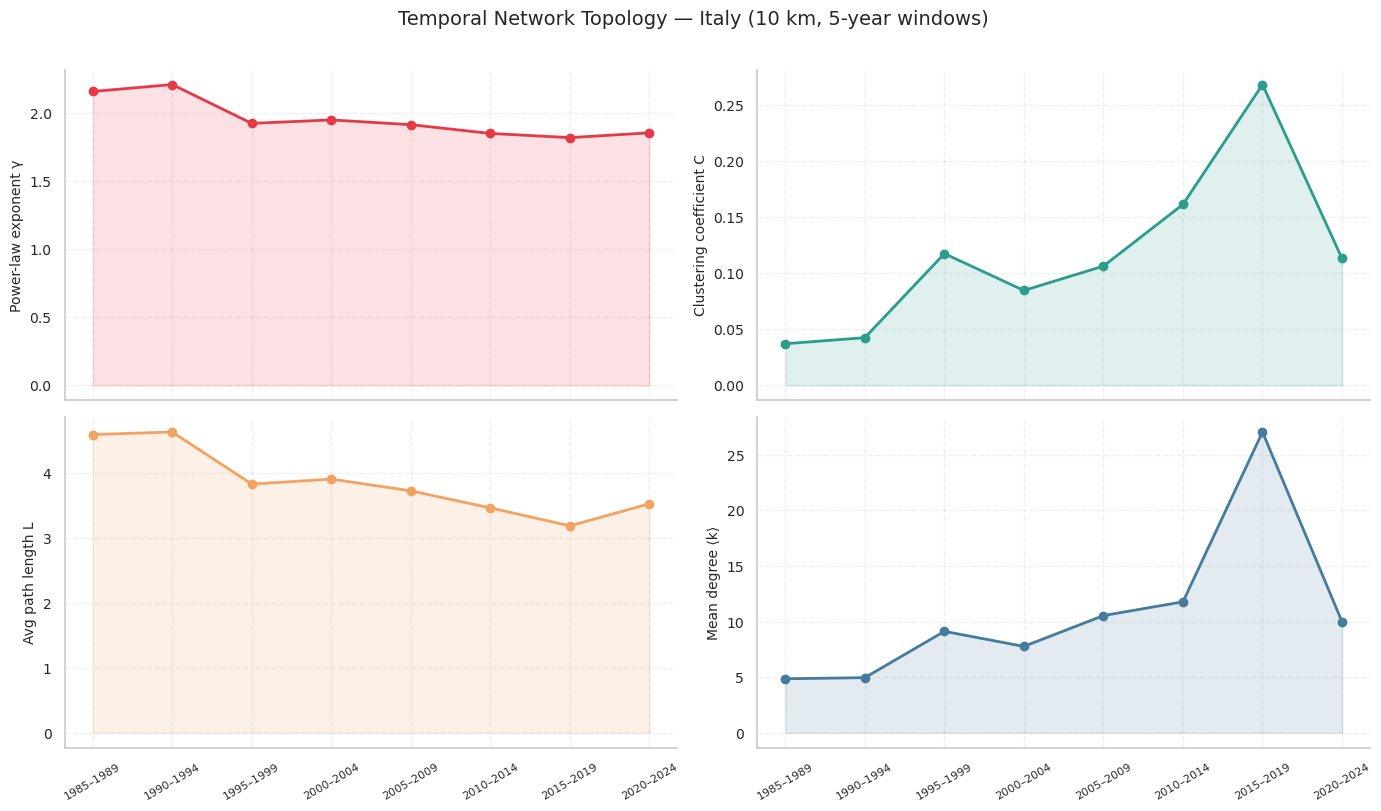

In [5]:
print("\nComputing Italy per-window topology metrics...")
df_metrics_italy = compute_temporal_metrics(
    italy_temporal, k_min_gamma=5, n_path_samples=100, seed=42
)
display(df_metrics_italy)
plot_temporal_metrics(df_metrics_italy, title="Italy (10 km, 5-year windows)")

## Per-Window Topology Metrics — US


Computing US per-window topology metrics...


INFO  1985–1989  n=7363  m=51057  γ=1.731  C=0.2837  L=3.024
INFO  1990–1994  n=7781  m=64065  γ=1.683  C=0.3263  L=2.953
INFO  1995–1999  n=7356  m=53227  γ=1.721  C=0.3295  L=3.013
INFO  2000–2004  n=8547  m=55794  γ=1.769  C=0.2746  L=3.070
INFO  2005–2009  n=8328  m=46738  γ=1.780  C=0.2879  L=3.121
INFO  2010–2014  n=9492  m=53961  γ=1.768  C=0.2365  L=3.168
INFO  2015–2019  n=10090  m=58123  γ=1.771  C=0.2109  L=3.182
INFO  2020–2024  n=10344  m=71838  γ=1.731  C=0.2988  L=3.018


,window,n_nodes,n_edges,mean_degree,gamma,clustering,avg_path_length
0,1985–1989,7363,51057,19.903,1.7308,0.2837,3.0242
1,1990–1994,7781,64065,27.074,1.6830,0.3263,2.9533
2,1995–1999,7356,53227,22.453,1.7210,0.3295,3.0134
3,2000–2004,8547,55794,18.670,1.7694,0.2746,3.0705
4,2005–2009,8328,46738,15.576,1.7798,0.2879,3.1214
5,2010–2014,9492,53961,16.762,1.7680,0.2365,3.1677
6,2015–2019,10090,58123,16.500,1.7706,0.2109,3.1825
7,2020–2024,10344,71838,19.911,1.7314,0.2988,3.0181


INFO  Saved results/figures/comparison/pdf/temporal_metrics_us_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_metrics_us_10_km_5_year_windows.jpg


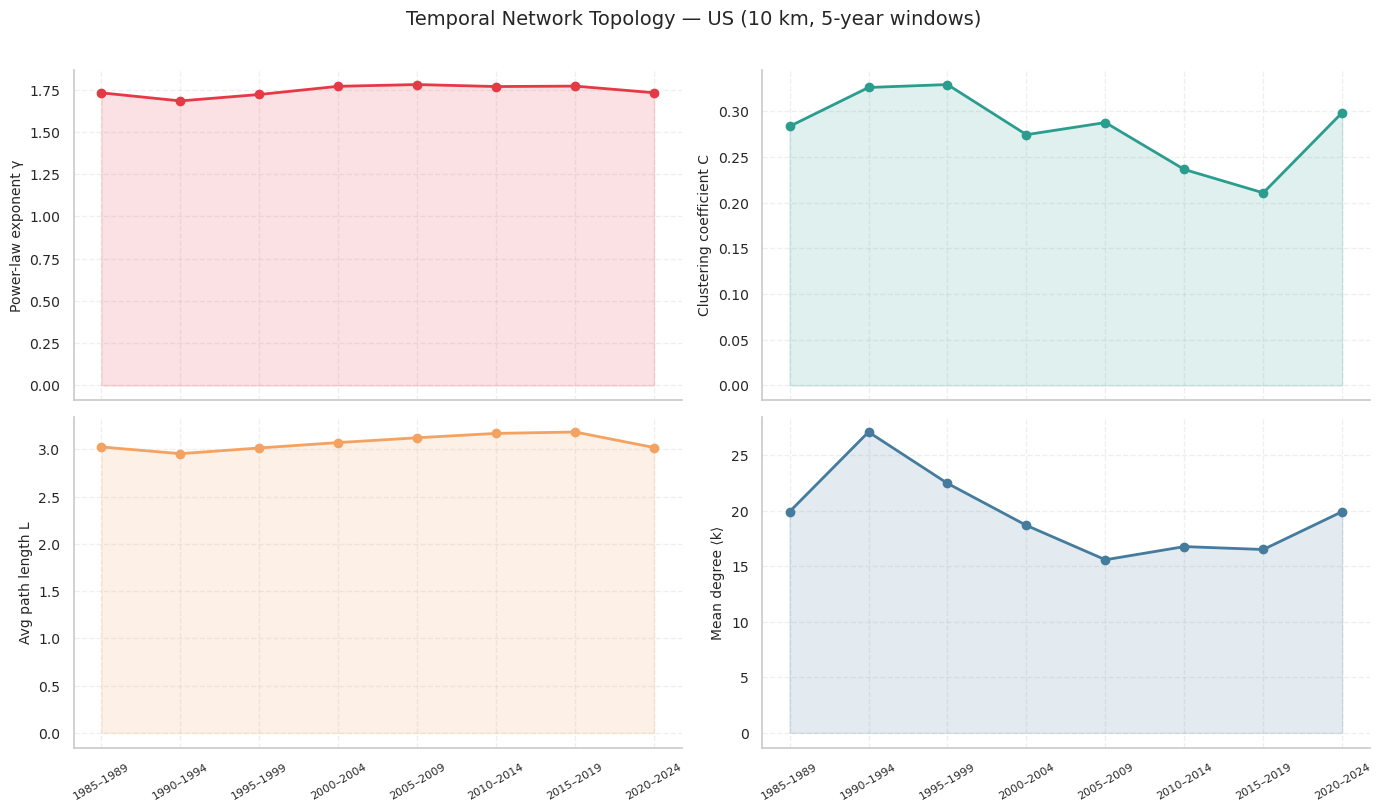

In [6]:
print("\nComputing US per-window topology metrics...")
df_metrics_us = compute_temporal_metrics(
    us_temporal, k_min_gamma=5, n_path_samples=100, seed=42
)
display(df_metrics_us)
plot_temporal_metrics(df_metrics_us, title="US (10 km, 5-year windows)")

## Italy vs US Metric Comparison

Side-by-side comparison reveals structural differences in temporal dynamics.
Italy's higher γ variance is expected given its episodic mainshock sequences
(L'Aquila 2009, Amatrice 2016) in the 40-year period.  The US network, dominated
by induced seismicity at The Geysers, may show a more stationary γ because
industrial injection rates are more constant than tectonic stress loading.

INFO  Saved results/figures/comparison/pdf/temporal_comparison_gamma_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_comparison_gamma_10_km_5_year_windows.jpg


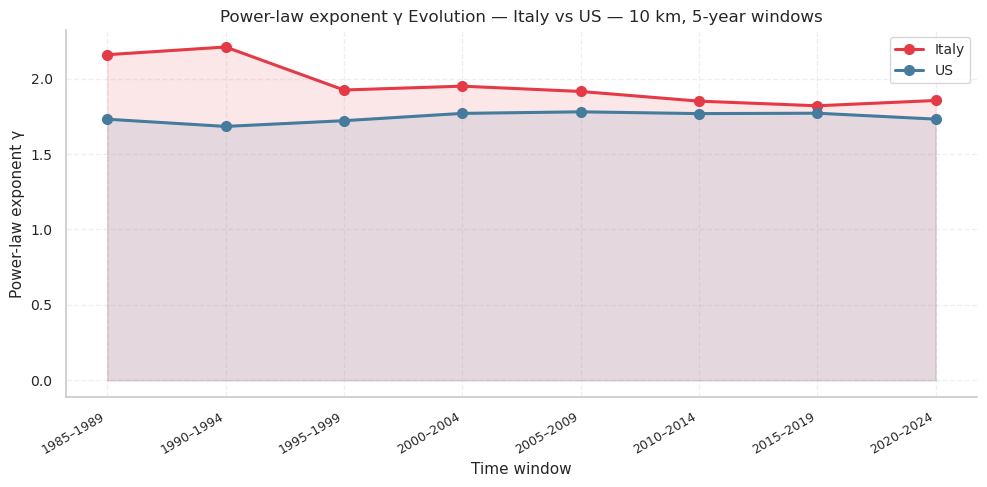

INFO  Saved results/figures/comparison/pdf/temporal_comparison_clustering_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_comparison_clustering_10_km_5_year_windows.jpg


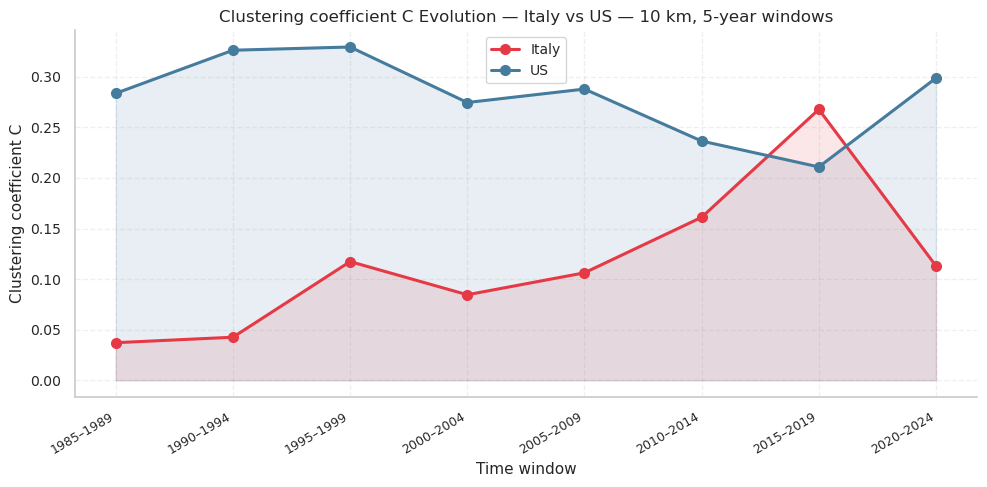

INFO  Saved results/figures/comparison/pdf/temporal_comparison_avg_path_length_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_comparison_avg_path_length_10_km_5_year_windows.jpg


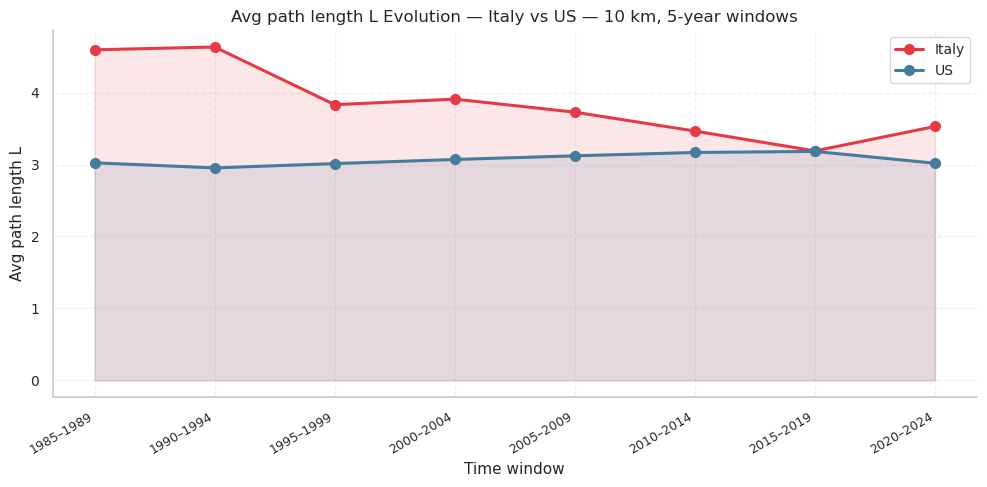

INFO  Saved results/figures/comparison/pdf/temporal_comparison_mean_degree_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_comparison_mean_degree_10_km_5_year_windows.jpg


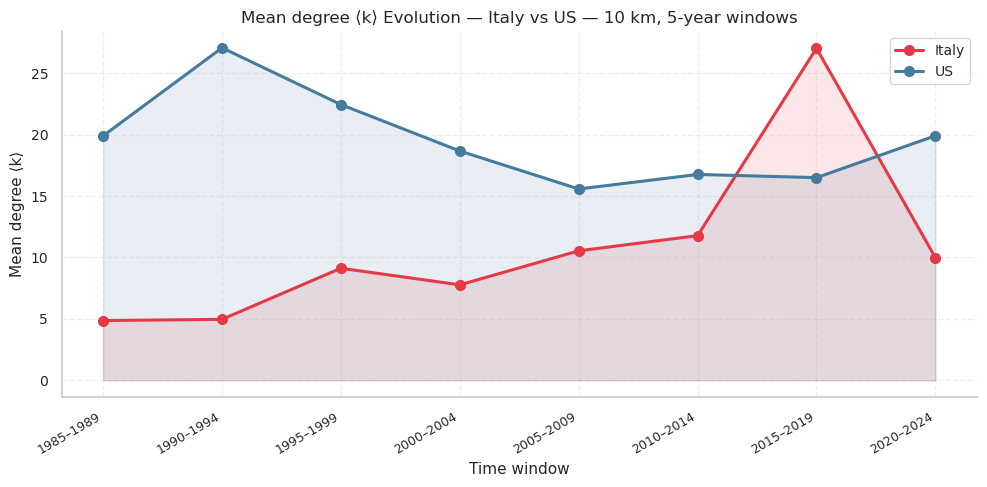

In [7]:
for metric, ylabel in [
    ("gamma",           "Power-law exponent γ"),
    ("clustering",      "Clustering coefficient C"),
    ("avg_path_length", "Avg path length L"),
    ("mean_degree",     "Mean degree ⟨k⟩"),
]:
    if metric in df_metrics_italy.columns and metric in df_metrics_us.columns:
        plot_temporal_comparison(
            df_metrics_italy, df_metrics_us,
            metric=metric, ylabel=ylabel,
            title="10 km, 5-year windows",
        )

## Partition Stability — Italy

NMI between Louvain partitions of consecutive windows (restricted to nodes
present in both windows).  NMI = 1 → identical community structure.
NMI ≈ 0 → completely reorganised communities.

High stability implies that tectonic provinces are persistent structural features
of the seismic network.  A stability drop co-occurring with a large mainshock
would indicate that the event reorganised the network's community structure —
testable by checking if the low-NMI window contains a known major earthquake.

In [8]:
print("\nComputing Italy partition stability across windows...")
df_stability_italy = compute_partition_stability(italy_temporal, seed=42)
display(df_stability_italy)

print("\nComputing US partition stability across windows...")
df_stability_us = compute_partition_stability(us_temporal, seed=42)
display(df_stability_us)


Computing Italy partition stability across windows...


INFO  1985–1989 → 1990–1994  NMI=0.1467  shared=1046
INFO  1990–1994 → 1995–1999  NMI=0.0916  shared=1290
INFO  1995–1999 → 2000–2004  NMI=0.0791  shared=954
INFO  2000–2004 → 2005–2009  NMI=0.0692  shared=1164
INFO  2005–2009 → 2010–2014  NMI=0.1450  shared=490
INFO  2010–2014 → 2015–2019  NMI=0.0386  shared=1647
INFO  2015–2019 → 2020–2024  NMI=0.0939  shared=719


,transition,nmi,shared_nodes
0,1985–1989 → 1990–1994,0.1467,1046
1,1990–1994 → 1995–1999,0.0916,1290
2,1995–1999 → 2000–2004,0.0791,954
3,2000–2004 → 2005–2009,0.0692,1164
4,2005–2009 → 2010–2014,0.1450,490
5,2010–2014 → 2015–2019,0.0386,1647
6,2015–2019 → 2020–2024,0.0939,719



Computing US partition stability across windows...


INFO  1985–1989 → 1990–1994  NMI=0.0200  shared=3250
INFO  1990–1994 → 1995–1999  NMI=0.0237  shared=2801
INFO  1995–1999 → 2000–2004  NMI=0.0445  shared=1179
INFO  2000–2004 → 2005–2009  NMI=0.0293  shared=2286
INFO  2005–2009 → 2010–2014  NMI=0.0345  shared=1836
INFO  2010–2014 → 2015–2019  NMI=0.0371  shared=1213
INFO  2015–2019 → 2020–2024  NMI=0.0318  shared=1722


,transition,nmi,shared_nodes
0,1985–1989 → 1990–1994,0.0200,3250
1,1990–1994 → 1995–1999,0.0237,2801
2,1995–1999 → 2000–2004,0.0445,1179
3,2000–2004 → 2005–2009,0.0293,2286
4,2005–2009 → 2010–2014,0.0345,1836
5,2010–2014 → 2015–2019,0.0371,1213
6,2015–2019 → 2020–2024,0.0318,1722


## Hub Persistence — Italy & US

Jaccard similarity of the top-20 PageRank hubs between consecutive windows.
Persistent hubs (high Jaccard) are structurally stable fault segments that
remain topologically dominant across decades — the backbone of seismic activity.
Transient hubs (low Jaccard) appear only in response to specific mainshock
sequences and vanish once the aftershock cluster decays.

In [9]:
print("\nComputing hub persistence (top-20 PageRank)...")
df_hub_italy = compute_hub_persistence(italy_temporal, top_n=TOP_N_HUBS)
df_hub_us    = compute_hub_persistence(us_temporal,    top_n=TOP_N_HUBS)
display(df_hub_italy.assign(catalog="Italy"))
display(df_hub_us.assign(catalog="US"))


Computing hub persistence (top-20 PageRank)...


,transition,jaccard,n_common,catalog
0,1985–1989 → 1990–1994,0.0,0,Italy
1,1990–1994 → 1995–1999,0.0,0,Italy
2,1995–1999 → 2000–2004,0.0,0,Italy
3,2000–2004 → 2005–2009,0.0,0,Italy
4,2005–2009 → 2010–2014,0.0,0,Italy
5,2010–2014 → 2015–2019,0.0,0,Italy
6,2015–2019 → 2020–2024,0.0,0,Italy


,transition,jaccard,n_common,catalog
0,1985–1989 → 1990–1994,0.0000,0,US
1,1990–1994 → 1995–1999,0.0256,1,US
2,1995–1999 → 2000–2004,0.0000,0,US
3,2000–2004 → 2005–2009,0.0000,0,US
4,2005–2009 → 2010–2014,0.0000,0,US
5,2010–2014 → 2015–2019,0.0000,0,US
6,2015–2019 → 2020–2024,0.0256,1,US


## Edge Turnover — Italy & US

Jaccard similarity of edge sets across consecutive windows.
Low turnover → stable seismic corridors (same cell-to-cell transitions
recur decade after decade, consistent with fixed fault geometry).
High turnover → rapid reorganisation (seismic pathways shift, possibly
driven by stress redistribution after large events).

In [10]:
print("\nComputing edge turnover...")
df_edge_italy = compute_edge_turnover(italy_temporal)
df_edge_us    = compute_edge_turnover(us_temporal)
display(df_edge_italy.assign(catalog="Italy"))
display(df_edge_us.assign(catalog="US"))


Computing edge turnover...


,transition,jaccard,n_common_edges,catalog
0,1985–1989 → 1990–1994,0.0005,10,Italy
1,1990–1994 → 1995–1999,0.0029,62,Italy
2,1995–1999 → 2000–2004,0.0007,16,Italy
3,2000–2004 → 2005–2009,0.0014,39,Italy
4,2005–2009 → 2010–2014,0.0001,6,Italy
5,2010–2014 → 2015–2019,0.0023,116,Italy
6,2015–2019 → 2020–2024,0.0005,23,Italy


,transition,jaccard,n_common_edges,catalog
0,1985–1989 → 1990–1994,0.0078,889,US
1,1990–1994 → 1995–1999,0.0053,614,US
2,1995–1999 → 2000–2004,0.0002,23,US
3,2000–2004 → 2005–2009,0.0014,141,US
4,2005–2009 → 2010–2014,0.0005,52,US
5,2010–2014 → 2015–2019,0.0002,18,US
6,2015–2019 → 2020–2024,0.0008,101,US


## Stability Summary — Italy

The three stability measures (community NMI, hub Jaccard, edge Jaccard) are
plotted together.  A window where all three drop simultaneously identifies a
seismic reorganisation event — a major mainshock that restructures the network.
Compare the dates of low-NMI / low-Jaccard windows with the catalog of M ≥ 6
events to test whether network reorganisation is mainshock-driven.

INFO  Saved results/figures/comparison/pdf/temporal_stability_italy_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_stability_italy_10_km_5_year_windows.jpg


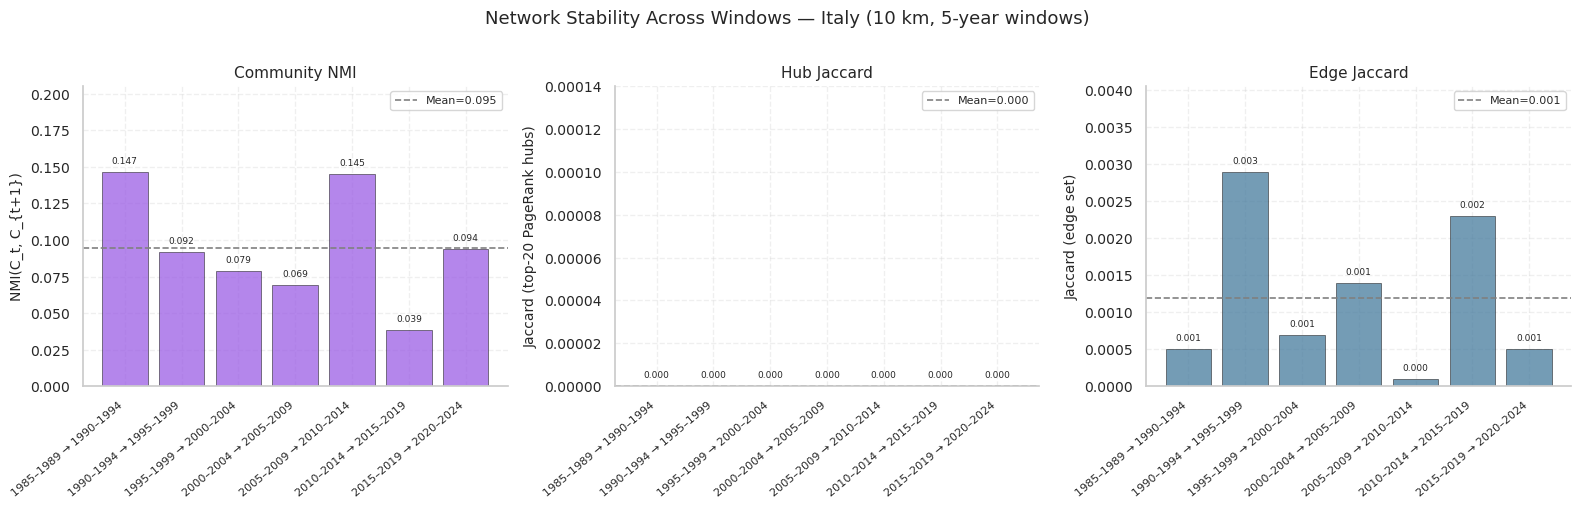

In [11]:
plot_temporal_stability(
    df_stability_italy, df_hub_italy, df_edge_italy,
    title="Italy (10 km, 5-year windows)",
)

## Stability Summary — US

INFO  Saved results/figures/comparison/pdf/temporal_stability_us_10_km_5_year_windows.pdf
INFO  Saved results/figures/comparison/jpg/temporal_stability_us_10_km_5_year_windows.jpg


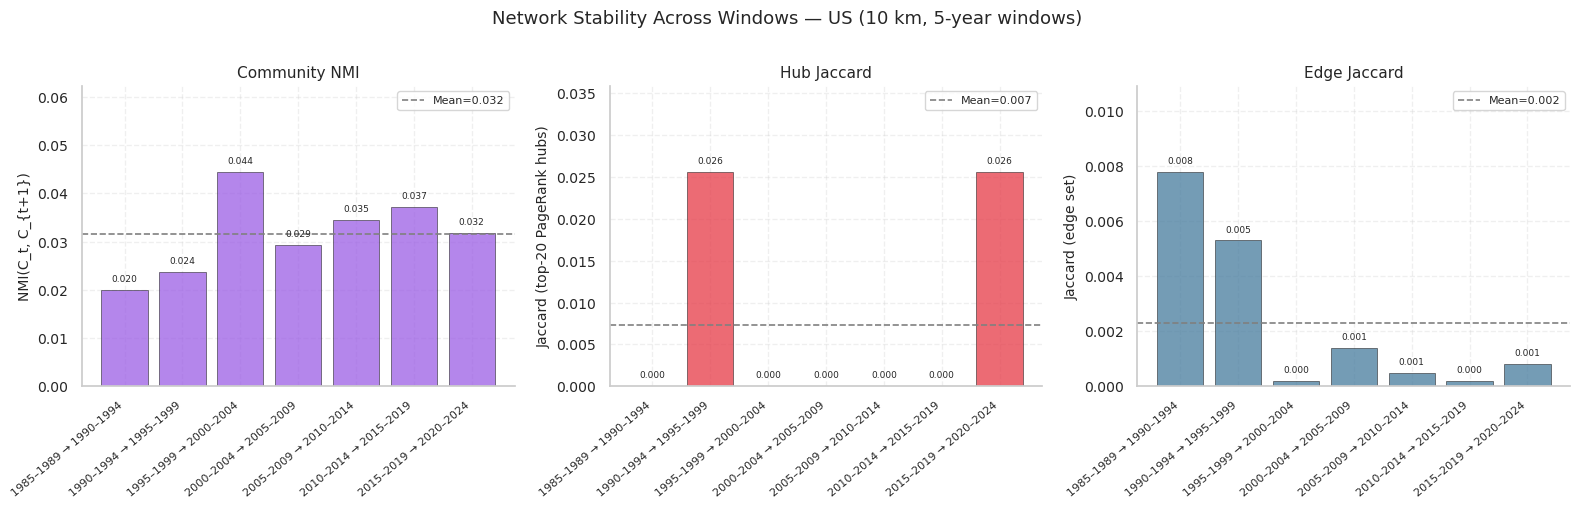

In [12]:
plot_temporal_stability(
    df_stability_us, df_hub_us, df_edge_us,
    title="US (10 km, 5-year windows)",
)

## Cross-Catalog Stability Comparison

Side-by-side bar chart of mean partition stability for Italy vs US.
A higher mean NMI for Italy would imply that its tectonic communities are
more geographically anchored (stable fault zones), while a higher mean for
the US would suggest that induced-seismicity hubs persist consistently
across decades (industrial injection at fixed geographic locations).

INFO  Saved results/figures/comparison/pdf/temporal_cross_catalog_stability.pdf
INFO  Saved results/figures/comparison/jpg/temporal_cross_catalog_stability.jpg


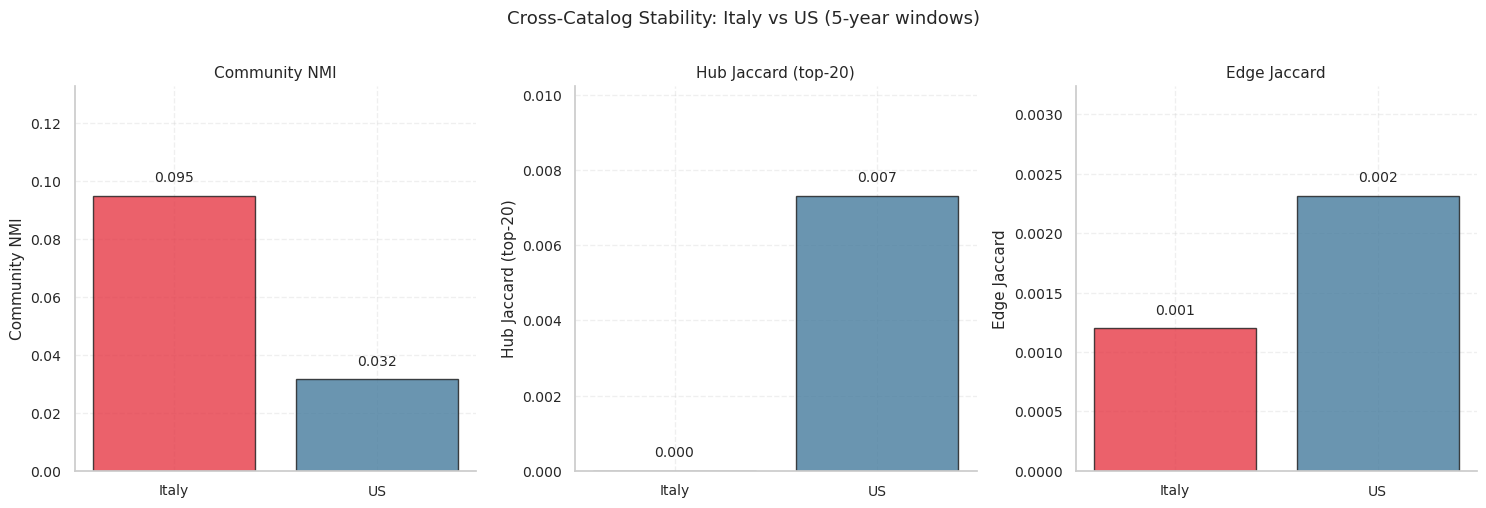

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_compare = [
    (df_stability_italy["nmi"],     df_stability_us["nmi"],     "Community NMI",       axes[0]),
    (df_hub_italy["jaccard"],       df_hub_us["jaccard"],       "Hub Jaccard (top-20)", axes[1]),
    (df_edge_italy["jaccard"],      df_edge_us["jaccard"],      "Edge Jaccard",         axes[2]),
]
for italy_vals, us_vals, ylabel, ax in metrics_compare:
    means = [float(np.nanmean(italy_vals)), float(np.nanmean(us_vals))]
    bars = ax.bar(["Italy", "US"], means,
                  color=["#e63946", "#457b9d"], alpha=0.8, edgecolor="k")
    vmax = max(max(means), 1e-4)
    ax.set_ylim(0, vmax * 1.4)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, v + vmax * 0.04,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11)
    ax.grid(axis="y", ls="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Cross-Catalog Stability: Italy vs US (5-year windows)", fontsize=13, y=1.01)
plt.tight_layout()
savefig("temporal_cross_catalog_stability")
plt.show()

## Export Results

All per-window DataFrames are exported to CSV for inclusion in the report.

In [14]:
out = RESULTS_DIR / "data"
out.mkdir(exist_ok=True)

df_metrics_italy.to_csv(out / "temporal_metrics_italy.csv", index=False)
df_metrics_us.to_csv(out / "temporal_metrics_us.csv", index=False)
df_stability_italy.to_csv(out / "temporal_stability_italy.csv", index=False)
df_stability_us.to_csv(out / "temporal_stability_us.csv", index=False)
df_hub_italy.to_csv(out / "temporal_hub_persistence_italy.csv", index=False)
df_hub_us.to_csv(out / "temporal_hub_persistence_us.csv", index=False)
df_edge_italy.to_csv(out / "temporal_edge_turnover_italy.csv", index=False)
df_edge_us.to_csv(out / "temporal_edge_turnover_us.csv", index=False)
print("\nAll temporal results saved to results/data/")

# Summary table
summary = pd.DataFrame({
    "metric": ["Mean γ", "γ std dev", "Mean C", "Mean L",
                "Mean community NMI", "Mean hub Jaccard", "Mean edge Jaccard"],
    "italy": [
        df_metrics_italy["gamma"].mean(), df_metrics_italy["gamma"].std(),
        df_metrics_italy["clustering"].mean(), df_metrics_italy["avg_path_length"].mean(),
        df_stability_italy["nmi"].mean(), df_hub_italy["jaccard"].mean(),
        df_edge_italy["jaccard"].mean(),
    ],
    "us": [
        df_metrics_us["gamma"].mean(), df_metrics_us["gamma"].std(),
        df_metrics_us["clustering"].mean(), df_metrics_us["avg_path_length"].mean(),
        df_stability_us["nmi"].mean(), df_hub_us["jaccard"].mean(),
        df_edge_us["jaccard"].mean(),
    ],
}).round(4)
print("\n=== Temporal Analysis Summary ===")
display(summary)
summary.to_csv(out / "temporal_summary.csv", index=False)


All temporal results saved to results/data/

=== Temporal Analysis Summary ===


,metric,italy,us
0,Mean γ,1.9604,1.7442
1,γ std dev,0.1453,0.0334
2,Mean C,0.1162,0.2810
3,Mean L,3.8609,3.0689
4,Mean community NMI,0.0949,0.0316
5,Mean hub Jaccard,0.0000,0.0073
6,Mean edge Jaccard,0.0012,0.0023
